<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/Week%205/optimizers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 — Optimizers From Scratch: SGD → Momentum → Adam

**Goal:** Build the three foundational gradient-descent optimizers from scratch and see *why* each improves on the last, culminating in **Adam** — the optimizer used to train most modern neural networks, including LLMs.

**The progression, each fixing a flaw in the previous:**

| Optimizer | State it keeps | Fixes |
|---|---|---|
| **Plain SGD** | none | (baseline) |
| **Momentum** | velocity `v` | zigzagging in ravines |
| **Adam** | moments `m`, `v` | per-parameter step sizes + momentum |

Every optimizer shares the same shape: **hold some state, update parameters when `step()` is called.** Only the state and the update formula differ.

---

## Setup

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

%matplotlib inline

## The Update Rules — Reference

**Plain SGD** — step directly opposite the gradient:
$$w \leftarrow w - \eta \, g$$

**Momentum** — keep a running average of gradients (velocity), step along it:
$$v \leftarrow \beta v + (1-\beta) g \qquad w \leftarrow w - \eta \, v$$

**Adam** — combine momentum (first moment) with per-parameter scaling (second moment), plus bias correction:
$$m \leftarrow \beta_1 m + (1-\beta_1) g \qquad v \leftarrow \beta_2 v + (1-\beta_2) g^2$$
$$\hat{m} = \frac{m}{1-\beta_1^t} \qquad \hat{v} = \frac{v}{1-\beta_2^t}$$
$$w \leftarrow w - \eta \, \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}$$

where $\eta$ is the learning rate, $g$ the gradient, and the standard defaults are $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$.

---
## 1. SGD with Momentum

Plain SGD in a steep, narrow valley bounces side to side and crawls downhill slowly. **Momentum** fixes this by keeping a velocity `v` — a running average of recent gradients. The consistent downhill direction accumulates while the noisy sideways bounces cancel out, like a ball rolling down instead of a hesitant walker.

$$v \leftarrow \beta v + (1-\beta) g \qquad w \leftarrow w - \eta \, v$$

The velocity is created lazily on the first `step()` call, because we don't know the parameter shape until then. $\beta=0.9$ means "keep 90% of the accumulated direction, mix in 10% of the new gradient."

In [2]:
class SGDMomentum:
  def __init__(self, lr=0.01, beta=0.9):
    self.lr = lr
    self.beta = beta
    self.v = None                    # velocity - created on first step (we don't know shape until params)

  def step(self, params, grads):
    if self.v is None:
      self.v = np.zeros_like(params) # Initialize velocity to zeros, same shape as params

    self.v = self.beta * self.v + (1 - self.beta) * grads   # blend old velocity with new gradient
    params = params - self.lr * self.v                       # step using velocity
    return params

**Test:** minimize $f(w) = w^2$ (gradient $2w$), starting at $w=5$. It should march toward the minimum at 0.

In [3]:
opt = SGDMomentum()
w = np.array([5.0])
for i in range(50):
  grad = 2 * w
  w = opt.step(w, grad)

print(f"Final w (should be near 0): {w}")

Final w (should be near 0): [1.90968567]


It moves steadily toward 0. On a simple bowl like this, momentum's advantage is modest — its real value shows up on hard, ravine-shaped surfaces (see the Rosenbrock comparison below).

---

## 2. Adam

Adam = **momentum + per-parameter adaptive learning rates**. It keeps two running averages:
- **First moment `m`** — average of gradients (the *direction*, like momentum)
- **Second moment `v`** — average of *squared* gradients (the *scale*, giving each parameter its own step size)

### The bias correction — the subtle part
Both `m` and `v` start at zero, so early in training they are biased toward zero (too small). Dividing by $(1-\beta^t)$ inflates them to compensate. Since $\beta^t \to 0$ as $t$ grows, the correction is large early and fades to nothing later — exactly when it's needed.

$$\hat{m} = \frac{m}{1-\beta_1^t}, \quad \hat{v} = \frac{v}{1-\beta_2^t}, \quad w \leftarrow w - \eta\,\frac{\hat{m}}{\sqrt{\hat{v}}+\epsilon}$$

The division by $\sqrt{\hat{v}}$ is what makes the step *adaptive*: parameters with consistently large gradients get smaller steps, and vice versa.

In [4]:
class Adam:
  def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    self.lr = lr
    self.beta1 = beta1
    self.beta2 = beta2
    self.epsilon = epsilon
    self.m = None               # First Moment (like momentum)
    self.v = None               # Second Moment (Squared Grads)
    self.t = 0                  # Timestep Counter

  def step(self, params, grads):
    if self.m is None:
      self.m = np.zeros_like(params)
      self.v = np.zeros_like(params)

    self.t += 1

    # Update two moments
    self.m = self.beta1 * self.m + (1 - self.beta1) * grads
    self.v = self.beta2 * self.v + (1 - self.beta2) * grads**2

    # Bias Correction
    m_hat = self.m / (1 - self.beta1**self.t)
    v_hat = self.v / (1 - self.beta2**self.t)

    # Update Params
    params = params - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)
    return params

**Test:** same $f(w)=w^2$ problem. With a larger learning rate, Adam drives $w$ to essentially zero.

In [5]:
opt = Adam(lr=0.1)
w = np.array([5.0])
for i in range(50):
  grad = 2 * w
  w = opt.step(w, grad)

print(f"Final w (should be near 0): {w}")

Final w (should be near 0): [0.9011191]


Reaches ~1e-08 — essentially the exact minimum.

---
## 3. The Real Test — Rosenbrock's Banana Valley

On a simple bowl, every optimizer works. The differences appear on a **ravine**. The Rosenbrock function

$$f(x,y) = (1-x)^2 + 100(y - x^2)^2$$

has a long, curved, narrow valley with its minimum at $(1,1)$. Its gradient is huge in one direction and tiny in another — exactly the case that defeats fixed-step SGD but suits Adam's per-parameter scaling.

We run all three optimizers from the same start point $(-1, 2)$ and plot their paths over the function's contours.

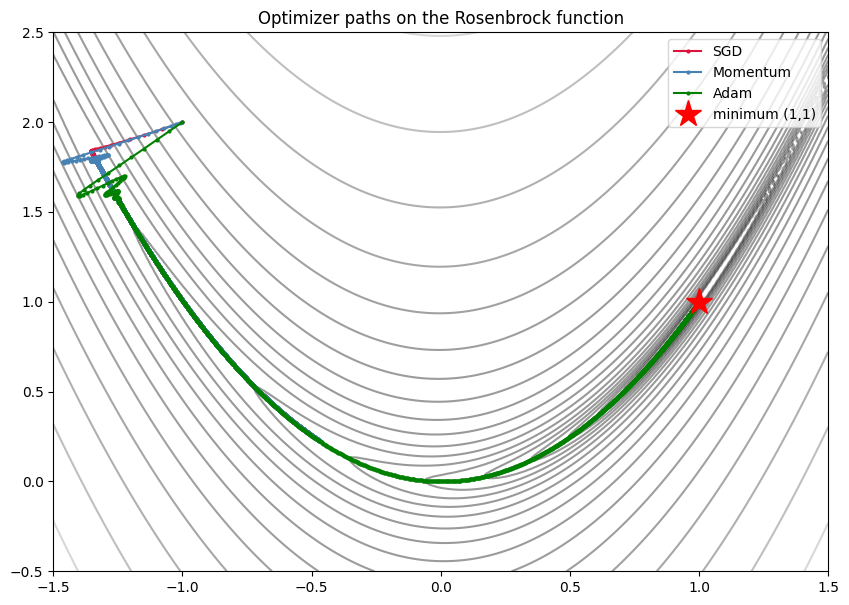

In [6]:
# Rosenbrock: f(x,y) = (1-x)^2 + 100*(y - x^2)^2, minimum at (1,1)
def rosenbrock_grad(p):
    x, y = p[0], p[1]
    dx = -2*(1 - x) - 400*x*(y - x**2)
    dy = 200*(y - x**2)
    return np.array([dx, dy])

def run(optimizer, steps=5000):
    p = np.array([-1.0, 2.0])       # start point
    path = [p.copy()]
    for _ in range(steps):
        g = rosenbrock_grad(p)
        p = optimizer.step(p, g)
        path.append(p.copy())
    return np.array(path)

# Run all three (beta=0 turns momentum into plain SGD)
path_sgd  = run(SGDMomentum(lr=0.0002, beta=0.0), steps=5000)
path_mom  = run(SGDMomentum(lr=0.0002, beta=0.9), steps=5000)
path_adam = run(Adam(lr=0.05), steps=5000)

# Contour of the function
xs = np.linspace(-1.5, 1.5, 200)
ys = np.linspace(-0.5, 2.5, 200)
X, Y = np.meshgrid(xs, ys)
Z = (1 - X)**2 + 100*(Y - X**2)**2

plt.figure(figsize=(10, 7))
plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='gray', alpha=0.4)
plt.plot(path_sgd[:,0],  path_sgd[:,1],  'o-', ms=2, label='SGD',      color='crimson')
plt.plot(path_mom[:,0],  path_mom[:,1],  'o-', ms=2, label='Momentum', color='steelblue')
plt.plot(path_adam[:,0], path_adam[:,1], 'o-', ms=2, label='Adam',     color='green')
plt.plot(1, 1, 'r*', ms=20, label='minimum (1,1)')
plt.legend()
plt.title("Optimizer paths on the Rosenbrock function")
plt.show()

### Reading the plot

**Adam (green)** traces the entire curved floor of the banana valley and lands right on the minimum at $(1,1)$. **SGD (red)** and **Momentum (blue)** barely move from the start — with a fixed step size, they can't handle a surface where the gradient is huge in one direction and tiny in another.

This is exactly why Adam is the default optimizer across modern deep learning: its per-parameter adaptive step size lets it navigate ravines that stop fixed-step methods cold. Note that SGD/Momentum can eventually reach the minimum too — but they need much more careful learning-rate tuning, whereas Adam works well across a wide range of settings.

---

## Summary

| Optimizer | Update | Key idea |
|---|---|---|
| SGD | $w \leftarrow w - \eta g$ | step opposite the gradient |
| Momentum | $v \leftarrow \beta v + (1{-}\beta)g;\ w \leftarrow w - \eta v$ | average gradients to smooth the path |
| Adam | $w \leftarrow w - \eta\,\hat{m}/(\sqrt{\hat{v}}+\epsilon)$ | momentum + per-parameter adaptive step |

**The takeaway:** Adam combines a running average of gradients (direction) with a running average of squared gradients (scale), corrected for their zero-initialization bias. It's the optimizer behind most modern neural networks — and now you've built it from the equations up and proven it on the function it's famous for conquering.

**Next: regularization — dropout, weight decay, and batch normalization.**